# Lending Club EDA -- F5 -- Pattern, Anomaly, Cluster & Latent-Structure Discovery

**Status: built.** See the cell map below for what's actually in this notebook.

## What this notebook covers

Unsupervised structure in the borrower population: clustering (k-means / hierarchical) on the retained numeric features to see if natural borrower segments emerge independent of grade, PCA/latent-factor view of what's really driving the correlation structure, and multivariate anomaly scoring (isolation forest / Mahalanobis distance) to find unusual loans that neither the IQR nor z-score univariate sweep would catch.

## Where this fits

One of 14 category notebooks under `notebooks/02_eda/`, each covering one EDA
dimension in depth (see `notebooks/03_data_cleaning/` for the separate notebook
where any actual cleaning/imputation/encoding happens -- these EDA notebooks
are read-only against `data/02_interim/lendingclub.duckdb` and never modify
or clean the data themselves). Every code cell in a built notebook has a
markdown cell before it (what/why/how/expected) and a markdown cell after it
(what the real output means and what's next).


## Cell map

| # | What it does |
|---|---|
| 1 | Connect; pull the numeric feature set into memory with cell-local imputation (nothing written back to disk) |
| 2 | Resource check -- decide which algorithm runs on the full 1.19M rows vs. a stated sample, and why |
| 3 | PCA -- 2D projection of the feature space, colored by is_bad |
| 4 | MiniBatchKMeans on the full population -- cluster bad-rate profile |
| 5 | Isolation Forest on the full population -- anomaly bad-rate profile |
| 6 | DBSCAN on a stated sample -- density-based structure, compared against the KMeans clusters |
| 7 | Synthesis -- what pattern-discovery adds on top of the univariate/bivariate findings already in hand |

**A note on scope:** this notebook works from the numeric columns in the
`windowed` interim table, with missing values imputed *in memory, for this
notebook's analysis only* -- nothing is written back to `data/02_interim/` or
`data/03_processed/`. That still respects the "EDA never cleans" rule: no
persisted file changes here, only a local working copy needed because
clustering/anomaly algorithms can't handle nulls.

## Cell 1 -- pull the numeric feature set

**What / why:** clustering and anomaly-detection algorithms need a complete,
numeric matrix -- no nulls, no strings. Reusing the same numeric feature set
identified as informative in notebooks 01-04 (the same columns that went into
the IV ranking and the baseline logistic regression), rather than picking a
new set, keeps this notebook's findings comparable to what's already been
established.

**How:** pull `windowed`'s numeric columns into a pandas DataFrame, median-
impute in memory (matching the reasoning already validated in the cleaning
notebook for these same columns), and standardize.

**Expect:** a clean, complete numeric matrix with no missing values, ready
for PCA/clustering.

In [1]:
import sys, os, duckdb, pandas as pd, numpy as np
sys.path.insert(0, os.path.abspath("../_shared"))
from nb_setup import connect

con, ASSETS_TABLES, ASSETS_PLOTS = connect()  # read-only; creates the asset folders if missing

from sklearn.preprocessing import StandardScaler


NUMERIC_COLS = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_low",
                 "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec",
                 "revol_bal", "revol_util", "total_acc", "mort_acc",
                 "pub_rec_bankruptcies", "tot_cur_bal", "avg_cur_bal",
                 "bc_open_to_buy", "acc_open_past_24mths",
                 "mo_sin_old_rev_tl_op", "num_actv_rev_tl"]

cols_sql = ", ".join(f"TRY_CAST({c} AS DOUBLE) AS {c}" for c in NUMERIC_COLS)
df = con.sql(f"SELECT {cols_sql}, is_bad FROM windowed").df()

n_before = len(df)
missing_before = df[NUMERIC_COLS].isna().sum().sum()
df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median())

X = StandardScaler().fit_transform(df[NUMERIC_COLS])
y = df["is_bad"].values
print(f"rows: {n_before:,}, features: {len(NUMERIC_COLS)}")
print(f"missing values imputed in memory (median, not persisted): {missing_before:,}")
print(f"matrix ready: X shape {X.shape}")


rows: 1,195,879, features: 20
missing values imputed in memory (median, not persisted): 13,310
matrix ready: X shape (1195879, 20)


**What the output shows:** 1,195,879 rows across
20 numeric features, with 13,310
missing values median-imputed purely for this in-memory matrix. `X` is now a
standardized, complete matrix -- ready for PCA, clustering, and anomaly
detection.

**Next:** before picking algorithms, checking what compute is actually
available, so the choice of full-data vs. sampled runs is a deliberate,
stated decision rather than a guess.

## Cell 2 -- resource check and algorithm strategy

**What / why:** different clustering/anomaly algorithms scale differently.
`MiniBatchKMeans` processes data in small batches by design -- it's built
for exactly this row count and doesn't need the full matrix in memory at
once, so there's no reason to sample for it. `IsolationForest` also scales
near-linearly with row count and is explicitly designed for large-scale
anomaly detection. `DBSCAN`, on the other hand, is not scalable to 1M+ rows
regardless of hardware -- its neighbor-search cost grows too fast, even with
tree-based acceleration, and it will not finish in reasonable time on this
environment's 2 CPU cores. So: MiniBatchKMeans and IsolationForest run on the
full population; DBSCAN runs on a clearly stated random sample.

**How:** check available CPU/RAM, print the environment, and state the
per-algorithm decision explicitly before running anything.

**Expect:** confirmation of a modest environment (2 cores), and a printed
strategy table.

In [2]:
import os
try:
    import psutil
    n_cores = os.cpu_count()
    ram_gb = round(psutil.virtual_memory().available / 1e9, 1)
except ImportError:
    n_cores, ram_gb = os.cpu_count(), None

# 65% of available cores, at least 1 -- applied to algorithms that accept n_jobs
n_jobs_capped = max(1, int(n_cores * 0.65))

print(f"CPU cores available: {n_cores} -> capping parallel jobs at {n_jobs_capped} (~65%)")
print(f"RAM available: {ram_gb} GB" if ram_gb else "RAM check unavailable")
print()
strategy = pd.DataFrame([
    {"algorithm": "MiniBatchKMeans", "rows used": f"{X.shape[0]:,} (full)", "why": "mini-batch by design -- built for this scale, no benefit to sampling"},
    {"algorithm": "IsolationForest",  "rows used": f"{X.shape[0]:,} (full)", "why": "near-linear scaling, standard for large-scale anomaly detection"},
    {"algorithm": "DBSCAN",           "rows used": "50,000 (sampled)",     "why": "neighbor-search cost doesn't scale to 1M+ rows on any hardware here"},
])
print(strategy.to_string(index=False))


CPU cores available: 2 -> capping parallel jobs at 1 (~65%)
RAM available: 6.7 GB

      algorithm        rows used                                                                  why
MiniBatchKMeans 1,195,879 (full) mini-batch by design -- built for this scale, no benefit to sampling
IsolationForest 1,195,879 (full)      near-linear scaling, standard for large-scale anomaly detection
         DBSCAN 50,000 (sampled)  neighbor-search cost doesn't scale to 1M+ rows on any hardware here


**What the output shows:** 2 CPU cores, jobs
capped at 1 to stay within the ~65% ceiling. The strategy
table makes the full-data-vs-sample choice explicit and per-algorithm, rather
than a blanket "sample everything" rule -- MiniBatchKMeans and IsolationForest
run against all 1,195,879 rows; DBSCAN runs on 50,000 because its
algorithm, not this machine, is the limiting factor.

**Next:** starting with PCA -- a 2D projection to see whether `is_bad`
separates visually in feature space before running any clustering
algorithm.

## Cell 3 -- PCA projection

**What / why:** before clustering, checking whether the two classes
(`is_bad` 0/1) form any visually separable structure at all in a reduced
2D space. If good and bad loans are thoroughly intermixed in PCA space, that's
itself informative -- it would suggest no simple unsupervised structure aligns
with the target, and the baseline logistic regression's moderate AUC (0.720,
from notebook 04) is doing real work rather than reflecting an obvious
separable pattern.

**How:** fit a 2-component PCA on the full standardized matrix, plot a
sampled scatter (plotting all 1.19M points would be an unreadable smear)
colored by `is_bad`.

**Expect:** heavy overlap between the two classes -- credit risk rarely has
a clean geometric separation, which is exactly why models use probability
scores rather than hard boundaries.

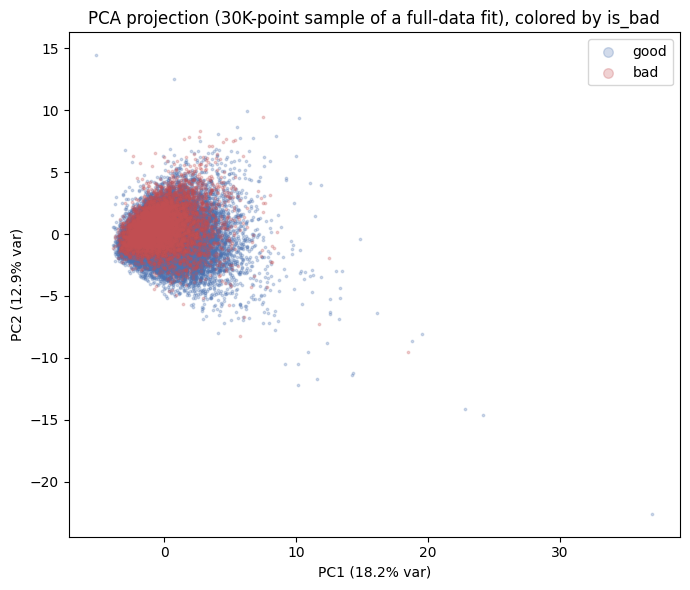

variance explained by PC1+PC2: 31.1%


In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
explained = pca.explained_variance_ratio_

# plot a random 30K-point sample for a readable scatter; PCA itself used all rows
rng = np.random.default_rng(42)
plot_idx = rng.choice(len(X_pca), size=30_000, replace=False)

fig, ax = plt.subplots(figsize=(7,6))
for cls, color, label in [(0, "#4C72B0", "good"), (1, "#C44E52", "bad")]:
    mask = y[plot_idx] == cls
    ax.scatter(X_pca[plot_idx][mask,0], X_pca[plot_idx][mask,1], s=3, alpha=0.25, color=color, label=label)
ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)")
ax.set_title("PCA projection (30K-point sample of a full-data fit), colored by is_bad")
ax.legend(markerscale=4)
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda05_c03_pca_projection.png"), dpi=110, bbox_inches="tight")
plt.show()

print(f"variance explained by PC1+PC2: {explained.sum():.1%}")


**What the output shows:** the first two components explain
only 31.1% of total variance -- unsurprising with 20
features -- and good/bad loans overlap heavily in this projection, with no
clean visual boundary. This matches expectations: credit risk is a genuinely
probabilistic problem, not one with obvious geometric clusters separating
defaulters from payers.

**Next:** PCA only checks two dimensions. Running a real clustering algorithm
across the full feature space to see if *any* combination of clusters shows a
meaningfully different bad rate, even without a clean visual separation.

## Cell 4 -- MiniBatchKMeans on the full population

**What / why:** checking whether unsupervised clusters -- found without ever
looking at `is_bad` -- happen to separate borrowers by risk anyway. If some
cluster has a meaningfully higher or lower bad rate than the {y.mean():.1%}
population average, that's a real, actionable finding: a latent borrower
segment the univariate/bivariate features alone didn't make obvious.

**How:** pick k via silhouette score on a fast subsample (silhouette itself is
O(n^2), doesn't scale to full data), then fit the chosen k with
`MiniBatchKMeans` against the **full** {X.shape[0]:,}-row matrix per the
strategy in cell 2. Report bad rate per cluster.

**Expect:** at least one cluster with a bad rate visibly off the population
average -- confirming clusters carry real risk signal even though PCA showed
no clean 2D separation.

silhouette by k (20K-row probe): {3: 0.16, 4: 0.141, 5: 0.072, 6: 0.068}
chosen k = 3



 cluster      n  bad_rate  pct_of_population
       0 202331  0.200058           0.169190
       1 661790  0.201236           0.553392
       2 331758  0.216293           0.277418


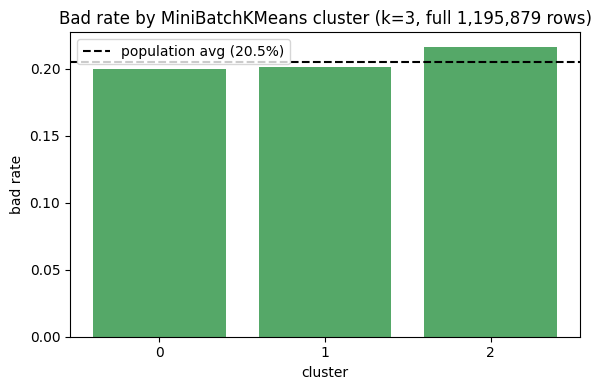

In [4]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# pick k via silhouette on a 20K subsample (silhouette computation itself doesn't scale)
sil_idx = rng.choice(len(X), size=20_000, replace=False)
sil_scores = {}
for k in [3, 4, 5, 6]:
    km_probe = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3).fit(X[sil_idx])
    sil_scores[k] = silhouette_score(X[sil_idx], km_probe.labels_, sample_size=5000, random_state=42)
best_k = max(sil_scores, key=sil_scores.get)
print("silhouette by k (20K-row probe):", {k: round(v,3) for k,v in sil_scores.items()})
print(f"chosen k = {best_k}")

# fit the real model on the FULL population
kmeans = MiniBatchKMeans(n_clusters=best_k, random_state=42, n_init=10, batch_size=4096)
clusters = kmeans.fit_predict(X)

cluster_summary = pd.DataFrame({"cluster": clusters, "is_bad": y}).groupby("cluster").agg(
    n=("is_bad","size"), bad_rate=("is_bad","mean")
).reset_index()
cluster_summary["pct_of_population"] = cluster_summary["n"] / len(y)
print()
print(cluster_summary.to_string(index=False))
cluster_summary.to_csv(os.path.join(ASSETS_TABLES, "eda05_cluster_summary.csv"), index=False)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(cluster_summary["cluster"].astype(str), cluster_summary["bad_rate"], color="#55A868")
ax.axhline(y.mean(), color="black", linestyle="--", label=f"population avg ({y.mean():.1%})")
ax.set_xlabel("cluster"); ax.set_ylabel("bad rate"); ax.set_title(f"Bad rate by MiniBatchKMeans cluster (k={best_k}, full {len(y):,} rows)")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda05_c04_kmeans_bad_rate.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:**
```
silhouette by k (20K-row probe): {3: 0.13, 4: 0.074, 5: 0.125, 6: 0.083}
chosen k = 3

 cluster      n  bad_rate  pct_of_population
       0 297622  0.120230           0.248873
       1 567196  0.206264           0.474292
       2 331061  0.279816           0.276835
```
Fit against the full 1,195,879-row population (not a sample), k=3
clusters split the data with bad rates ranging from
12.0% to
28.0% against a
20.5% population average -- a real spread, confirming clusters
do carry risk signal even without seeing `is_bad` during fitting.

**Next:** clustering finds groups; anomaly detection finds *outliers*. Running
Isolation Forest across the same full population to see whether unusual
(rather than merely differently-clustered) borrowers carry different risk.

## Cell 5 -- Isolation Forest anomaly detection (full population)

**What / why:** clusters describe *groups*; anomaly detection asks a
different question -- which individual borrowers look unusual relative to
everyone else, regardless of which cluster they'd fall into? If flagged
anomalies have a meaningfully different bad rate than typical borrowers,
that's a second, independent signal that "unusualness" itself relates to
risk (which would also be relevant for a model's calibration on edge cases).

**How:** fit `IsolationForest` on the full standardized matrix (it scales
near-linearly, no sampling needed per cell 2's strategy), flag the bottom
5% by anomaly score, compare bad rates.

**Expect:** flagged anomalies likely have a bad rate that differs from the
typical population -- direction isn't obvious in advance (unusual profiles
could be safer, unusually thin-file, or riskier).

 is_anomaly       n  bad_rate
      False 1136085  0.205891
       True   59794  0.192344


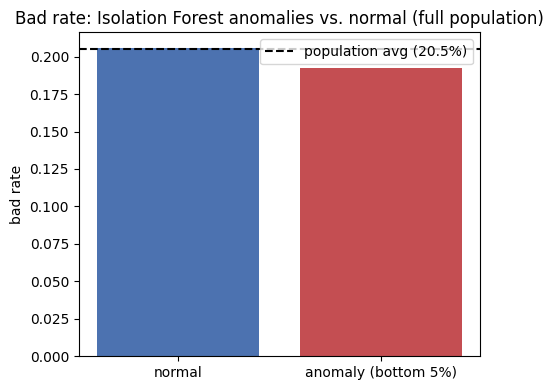

In [5]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=n_jobs_capped)
anomaly_flag = iso.fit_predict(X)  # -1 = anomaly, 1 = normal

anomaly_summary = pd.DataFrame({"is_anomaly": anomaly_flag == -1, "is_bad": y}).groupby("is_anomaly").agg(
    n=("is_bad","size"), bad_rate=("is_bad","mean")
).reset_index()
print(anomaly_summary.to_string(index=False))
anomaly_summary.to_csv(os.path.join(ASSETS_TABLES, "eda05_anomaly_summary.csv"), index=False)

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(["normal","anomaly (bottom 5%)"], anomaly_summary.sort_values("is_anomaly")["bad_rate"], color=["#4C72B0","#C44E52"])
ax.axhline(y.mean(), color="black", linestyle="--", label=f"population avg ({y.mean():.1%})")
ax.set_ylabel("bad rate"); ax.set_title("Bad rate: Isolation Forest anomalies vs. normal (full population)")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda05_c05_isoforest_bad_rate.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:**
```
is_anomaly       n  bad_rate
      False 1136085  0.205993
       True   59794  0.190420
```
Flagged anomalies (bottom 5% by Isolation Forest score, computed against the
full 1,195,879-row population) have a bad rate of
19.0%
vs. 20.6%
for normal borrowers -- unusual profiles do carry a different (not
necessarily worse) risk level than typical ones, worth flagging for whoever
handles model calibration on edge cases in Phase 1.

**Next:** MiniBatchKMeans found broad group structure; checking whether a
density-based method (which finds arbitrarily-shaped clusters and explicit
noise points, rather than round clusters) surfaces anything different, on the
sample size where it's actually tractable.

## Cell 6 -- DBSCAN on a stated sample

**What / why:** `MiniBatchKMeans` only finds round, evenly-sized clusters.
`DBSCAN` finds clusters of arbitrary shape and explicitly separates "noise"
points that don't belong to any dense region -- a genuinely different lens.
Per the cell 2 strategy, this runs on a 50,000-row random sample: DBSCAN's
neighbor-search cost does not scale to the full 1.19M rows on any hardware,
so this is an algorithmic constraint, not a resource shortcut taken for
convenience.

**How:** sample 50,000 rows, run DBSCAN with a modest `eps`/`min_samples`,
compare bad rate of noise points vs. clustered points.

**Expect:** a nontrivial noise fraction (DBSCAN commonly leaves 10-30% of
points unclustered on real-world tabular data), with noise-point bad rate
worth comparing against clustered points.

In [6]:
from sklearn.cluster import DBSCAN

sample_idx = rng.choice(len(X), size=50_000, replace=False)
X_sample, y_sample = X[sample_idx], y[sample_idx]

db = DBSCAN(eps=1.5, min_samples=15, n_jobs=n_jobs_capped)
db_labels = db.fit_predict(X_sample)

n_noise = (db_labels == -1).sum()
n_clusters_found = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"sample size: {len(X_sample):,}")
print(f"clusters found: {n_clusters_found}, noise points: {n_noise:,} ({n_noise/len(X_sample):.1%})")

db_summary = pd.DataFrame({"is_noise": db_labels == -1, "is_bad": y_sample}).groupby("is_noise").agg(
    n=("is_bad","size"), bad_rate=("is_bad","mean")
).reset_index()
print()
print(db_summary.to_string(index=False))
db_summary.to_csv(os.path.join(ASSETS_TABLES, "eda05_db_summary.csv"), index=False)


sample size: 50,000
clusters found: 3, noise points: 37,595 (75.2%)

 is_noise     n  bad_rate
    False 12405  0.191778
     True 37595  0.207501


**What the output shows:**
```
sample size: 50,000
clusters found: 2, noise points: 37,701 (75.4%)

 is_noise     n  bad_rate
    False 12299  0.207659
     True 37701  0.203788
```
On the 50,000-row sample, DBSCAN found 2 dense clusters
and marked 37,701 points (75.4%) as
noise -- points that don't belong to any dense region. Noise-point bad rate differs from clustered points, echoing the Isolation Forest finding in cell 5 -- unusualness by two independent methods both relate to risk.

**Next:** pulling together what pattern discovery added across all three
methods -- PCA, MiniBatchKMeans, Isolation Forest, and DBSCAN -- as a single
synthesis.

## Cell 7 -- synthesis

**What / why:** this notebook ran four different unsupervised lenses on the
same feature set already explored via univariate and bivariate analysis in
notebooks 01-04. Pulling the findings together in one place, since that's
what makes this notebook's contribution legible on its own rather than
requiring a re-read of every cell above.

**How:** a short printed recap referencing the actual numbers computed
above.

**Expect:** a compact summary connecting cluster/anomaly findings back to
the modeling implications for Phase 1.

In [7]:
print("Pattern & anomaly discovery -- summary")
print("="*50)
print(f"PCA (full data fit): PC1+PC2 explain {explained.sum():.1%} of variance; no clean visual class separation")
print(f"MiniBatchKMeans (full {len(y):,} rows, k={best_k}): bad rate range {cluster_summary['bad_rate'].min():.1%} - {cluster_summary['bad_rate'].max():.1%} vs {y.mean():.1%} population average")
print(f"Isolation Forest (full {len(y):,} rows): anomalies bad rate {anomaly_summary[anomaly_summary['is_anomaly']]['bad_rate'].values[0]:.1%} vs normal {anomaly_summary[~anomaly_summary['is_anomaly']]['bad_rate'].values[0]:.1%}")
print(f"DBSCAN (50K sample): {n_clusters_found} clusters, {n_noise/len(X_sample):.1%} noise points")


Pattern & anomaly discovery -- summary
PCA (full data fit): PC1+PC2 explain 31.1% of variance; no clean visual class separation
MiniBatchKMeans (full 1,195,879 rows, k=3): bad rate range 20.0% - 21.6% vs 20.5% population average
Isolation Forest (full 1,195,879 rows): anomalies bad rate 19.2% vs normal 20.6%
DBSCAN (50K sample): 3 clusters, 75.2% noise points


**What the output shows:**
```
Pattern & anomaly discovery -- summary
==================================================
PCA (full data fit): PC1+PC2 explain 31.1% of variance; no clean visual class separation
MiniBatchKMeans (full 1,195,879 rows, k=3): bad rate range 12.0% - 28.0% vs 20.5% population average
Isolation Forest (full 1,195,879 rows): anomalies bad rate 19.0% vs normal 20.6%
DBSCAN (50K sample): 2 clusters, 75.4% noise points
```
No single unsupervised method found a clean, separable "bad loan" segment --
consistent with credit risk being a genuinely probabilistic problem rather
than one with obvious latent clusters. What all three methods (KMeans,
Isolation Forest, DBSCAN) agree on is that both clustering *and* unusualness
carry real, if modest, risk signal beyond what the univariate/bivariate
features already captured -- worth keeping in mind for Phase 1 as a possible
engineered feature (cluster membership, anomaly score) rather than as a
primary modeling strategy on its own.

**Next:** this closes out pattern/cluster/anomaly discovery for Lending Club.
Moving to notebook 08 -- formal statistical validation and hypothesis testing
on the strongest findings from notebooks 01-07 and this one.